# Finding Molecules Similar in Behavior/Function to Rapamycin - Data Extraction and Exploration

In this notebook, I want to go through the data and do some EDA to try to understand how the data works, and what we can do about it

Here are some initial notes from looking online: 

Questions I have are:

- What are morgan fingerprints?

Looking online, there are kernels that extract features of a molecule, hash them, and use the hash to determine bits that should be set. Typical fingerprint sizes are 1-4K bits.

To calculate similarity between fingerprints, we have the Tanimoto similarity function: 

$Tani(V_i , V_j) = \frac{V_j • V_j}{\sum_b V_{ib} + \sum_b V_{jb} - V_j • V_j}$

This function is one of the different kinds of algorithms used to determine similarity

- How do we load in the morgan fingerprints of each data molecule?

We can potentially do this using RDKit
- How do we manipulate the morgan fingerprints of each molecule?

In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem, DataStructs
from rdkit.Chem import PandasTools, Draw
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from pathlib import Path 

We gotta start off being able to load in the file/s

In [2]:
# Get the project root string to build off of
def find_project_root():
    p = Path.cwd()
    for parent in [p, *p.parents]:
        if (parent / ".git").exists():
            return parent
    raise FileNotFoundError("Project root (with .git) not found")

In [3]:
# Get the name of the sdf file you're looking for from the data file (in case you don't want to actually load everything)
def get_sdf_file_name(name: str):
    PROJECT_ROOT = find_project_root()
    DATA_DIR = PROJECT_ROOT / "data" 
    return DATA_DIR / name

In [4]:
# Load in the sdf file into a pandas dataframe
def load_sdf_file(name: str):
    file_str = get_sdf_file_name(name)
    df = PandasTools.LoadSDF(file_str)
    return df

In [5]:
# Load in a test sdf file to see if we can even load a small sdf file
df = load_sdf_file('test.sdf')

In [6]:
df.head()
# Looking here, the 'ROMol' column has 'rdkit.Chem.rdchem.Mol' objects
# This can be used to get the Morgan Fingerprints

,PUBCHEM_COMPOUND_CID,PUBCHEM_COMPOUND_CANONICALIZED,PUBCHEM_CACTVS_COMPLEXITY,PUBCHEM_CACTVS_HBOND_ACCEPTOR,PUBCHEM_CACTVS_HBOND_DONOR,PUBCHEM_CACTVS_ROTATABLE_BOND,PUBCHEM_CACTVS_SUBSKEYS,PUBCHEM_IUPAC_OPENEYE_NAME,PUBCHEM_IUPAC_CAS_NAME,PUBCHEM_IUPAC_NAME_MARKUP,...,PUBCHEM_BOND_UDEF_STEREO_COUNT,PUBCHEM_ISOTOPIC_ATOM_COUNT,PUBCHEM_COMPONENT_COUNT,PUBCHEM_CACTVS_TAUTO_COUNT,PUBCHEM_COORDINATE_TYPE,PUBCHEM_BONDANNOTATIONS,ID,ROMol,PUBCHEM_XLOGP3_AA,PUBCHEM_NONSTANDARDBOND
0,135,1,125,3,2,1,AAADcYBgMAAAAAAAAAAAAAAAAAAAAAAAAAAwAAAAAAAAAA...,4-hydroxybenzoic acid,4-hydroxybenzoic acid,4-hydroxybenzoic acid,...,0,0,1,-1,1\n5\n255,4 5 8\n4 6 8\n5 8 8\n6 9 8\n7 8 8\n7...,135,<rdkit.Chem.rdchem.Mol object at 0xf3a2e233f300>,NaN,NaN
1,338,1,133,3,2,1,AAADcYBgMAAAAAAAAAAAAAAAAAAAAAAAAAAwAAAAAAAAAA...,2-hydroxybenzoic acid,2-hydroxybenzoic acid,2-hydroxybenzoic acid,...,0,0,1,-1,1\n5\n255,4 5 8\n4 6 8\n5 7 8\n6 8 8\n7 9 8\n8...,338,<rdkit.Chem.rdchem.Mol object at 0xf3a2e233f3e0>,NaN,NaN
2,1983,1,139,2,2,1,AAADccByMAAAAAAAAAAAAAAAAAAAAAAAAAAwAAAAAAAAAA...,N-(4-hydroxyphenyl)acetamide,N-(4-hydroxyphenyl)acetamide,<I>N</I>-(4-hydroxyphenyl)acetamide,...,0,0,1,-1,1\n5\n255,4 5 8\n4 6 8\n5 7 8\n6 8 8\n7 9 8\n8...,1983,<rdkit.Chem.rdchem.Mol object at 0xf3a2e233f4c0>,NaN,NaN
3,2244,1,212,4,1,3,AAADccBwOAAAAAAAAAAAAAAAAAAAAAAAAAAwAAAAAAAAAA...,2-acetoxybenzoic acid,2-acetyloxybenzoic acid,2-acetyloxybenzoic acid,...,0,0,1,-1,1\n5\n255,5 6 8\n5 7 8\n6 8 8\n7 9 8\n8 10 8\n...,2244,<rdkit.Chem.rdchem.Mol object at 0xf3a2e233f5a0>,NaN,NaN
4,4064,1,212,4,2,8,AAADceBzOAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,[2-(carbamoyloxymethyl)-2-methyl-pentyl] carba...,carbamic acid [2-(carbamoyloxymethyl)-2-methyl...,[2-(carbamoyloxymethyl)-2-methylpentyl] carbamate,...,0,0,1,-1,1\n5\n255,NaN,4064,<rdkit.Chem.rdchem.Mol object at 0xf3a2e233f680>,NaN,NaN


In [7]:
Mols = df[['PUBCHEM_IUPAC_OPENEYE_NAME', 'ROMol']].copy()
Mols.head()

,PUBCHEM_IUPAC_OPENEYE_NAME,ROMol
0,4-hydroxybenzoic acid,<rdkit.Chem.rdchem.Mol object at 0xf3a2e233f300>
1,2-hydroxybenzoic acid,<rdkit.Chem.rdchem.Mol object at 0xf3a2e233f3e0>
2,N-(4-hydroxyphenyl)acetamide,<rdkit.Chem.rdchem.Mol object at 0xf3a2e233f4c0>
3,2-acetoxybenzoic acid,<rdkit.Chem.rdchem.Mol object at 0xf3a2e233f5a0>
4,[2-(carbamoyloxymethyl)-2-methyl-pentyl] carba...,<rdkit.Chem.rdchem.Mol object at 0xf3a2e233f680>


This is an example of how to use Tanimoto and Cosine Similarity

In [8]:
# Created molecules with smiles for CO2 and CCO 
mol1 = Chem.MolFromSmiles('COO') 
mol2 = Chem.MolFromSmiles('CCO')

# Create a generator for morgan fingerprint
fpgen = GetMorganGenerator(radius=2, fpSize=2048)

# Create the fingerprints
fp1 = fpgen.GetFingerprint(mol1)
fp2 = fpgen.GetFingerprint(mol2)
print(fp1)

# Get the similarities
tsimilarity = DataStructs.TanimotoSimilarity(fp1, fp2) # Above 0.85 is similar
csimilarity = DataStructs.CosineSimilarity(fp1, fp2) # -1 to 1 where 1 is the same direction
print(f"Tanimoto Similarity: {tsimilarity}")
print(f"Cosine similarity: {csimilarity}")



Tanimoto Similarity: 0.2
Cosine similarity: 0.3333333333333333


Okay, now that I have a decent pipeline for loading in molecules from sdf files and comparing them using Tanimoto and Cosine similarity, I'm going to have rapamycin as the target and compare different drug's similarities to it

In [9]:
# This will automatically load it into a pandas df, then extract the ROMol col (rdkit.Chem.rdchem.Mol object) 
rapamycin_mol = load_sdf_file('rapamycin.sdf')['ROMol'].iloc[0]
tests = load_sdf_file('test.sdf')

In [10]:
def to_mfp(molecule: Chem.rdchem.Mol, radius=2, fpSize=2048):
    # Get the generator with the 'hyperparameters'
    fpgen = GetMorganGenerator(radius=radius, fpSize=fpSize)
    
    # Get the fingerprint
    fp = fpgen.GetFingerprint(molecule)
    return fp

In [11]:
def to_mfps(df: pd, radius=2, fpSize=2048):
    # Turns a loaded sdf file (from pubchem only so far) to a list of morgan fingerprints
    
    # Get the ROMol column
    ROMols = df['ROMol']

    # Get the generator
    # Radius and bitsize could be hyperparameters in the future
    fpgen = GetMorganGenerator(radius=radius, fpSize=fpSize)

    # Create the fingerprints using vectorized method
    fp_list = fpgen.GetFingerprints(ROMols)

    return list(fp_list)

In [12]:
def get_tanimoto_similarities(target: DataStructs.cDataStructs.ExplicitBitVect, molecules: list):
    # BulkTaniotoSimilarity has to take in a list of molecules
    tsimilarities = DataStructs.cDataStructs.BulkTanimotoSimilarity(target, molecules)
    return tsimilarities

In [13]:
def get_cosine_similarities(target: DataStructs.cDataStructs.ExplicitBitVect, molecules: list):
    # BulkTaniotoSimilarity has to take in a list of molecules
    csimilarities = DataStructs.cDataStructs.BulkCosineSimilarity(target, molecules)
    return csimilarities

In [14]:
test_fp_list = to_mfps(tests)
rapamycin = to_mfp(rapamycin_mol)

print(test_fp_list)

[<rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0xf3a2e0d4bc30>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0xf3a2e0d4b760>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0xf3a2e0d4bca0>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0xf3a2e0d4bd10>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0xf3a2e0d4bd80>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0xf3a2e0d4bdf0>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0xf3a2e0d4be60>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0xf3a2e0d4bed0>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0xf3a2e0d4bf40>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0xf3a2e0b88040>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0xf3a2e0b880b0>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0xf3a2e0b88120>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0xf3a2e0b88190>, <rdkit.DataStructs.cData

In [15]:
test_tanimotos = np.array(get_tanimoto_similarities(rapamycin, test_fp_list))
print(test_tanimotos)
print(f'\nLargest Tanimoto similarity index: {np.argmax(test_tanimotos)}')
print(f'Largest Tanimoto similarity: {test_tanimotos.max()}')

[0.03571429 0.03508772 0.0619469  0.05982906 0.04237288 0.04098361
 0.04464286 0.05882353 0.04347826 0.05882353 0.05785124 0.03539823
 0.04310345 0.05932203 0.07142857 0.08053691 0.06451613 0.05882353
 0.07518797 0.08029197 0.06779661 0.0661157  0.04310345 0.05882353
 0.07758621 0.04201681 0.07086614 0.07692308 0.05882353 0.03636364
 0.05882353 0.08284024 0.07874016 0.10144928 0.07185629 0.07142857
 0.05882353 0.07575758 0.07086614 0.08270677 0.05882353 0.09027778
 0.10650888 0.08       0.04098361 0.07751938 0.064      0.0661157
 0.05785124 0.04098361 0.06722689 0.06015038 0.12435233 0.1369863
 0.06722689 0.06015038 0.03875969 0.08461538 0.07534247 0.07692308
 0.09655172 0.09395973 0.0703125  0.07086614 0.06557377 0.04273504
 0.046875   0.04615385 0.13366337 0.05833333 0.05833333 0.05785124
 0.07575758 0.05932203 0.07792208 0.03816794 0.05691057 0.05982906
 0.05882353 0.05882353 0.05882353 0.07801418 0.13836478 0.07462687
 0.08387097 0.05970149 0.12837838 0.06766917 0.07633588 0.068027

In [16]:
test_cosines = np.array(get_cosine_similarities(rapamycin, test_fp_list))
print(test_cosines)
print(f'\nLargest cosine similarity index: {np.argmax(test_cosines)}')
print(f'Largest cosine similarity: {test_cosines.max()}')

[0.1        0.0942809  0.15652476 0.1428869  0.10425721 0.09622504
 0.12126781 0.13728129 0.1118034  0.13728129 0.13228757 0.09701425
 0.10910895 0.14       0.15212777 0.15364426 0.14142136 0.13728129
 0.15249857 0.15877132 0.15689291 0.14855627 0.10910895 0.13728129
 0.18       0.10206207 0.15       0.15811388 0.13728129 0.1069045
 0.12060454 0.15366996 0.16439899 0.19414507 0.13501055 0.13643821
 0.13728129 0.15430335 0.15       0.16583124 0.13728129 0.17218921
 0.19298026 0.16903085 0.09622504 0.16012815 0.13926212 0.14855627
 0.13228757 0.09622504 0.15396007 0.12493901 0.22188008 0.24618298
 0.15396007 0.12493901 0.08574929 0.17179114 0.14569856 0.15811388
 0.18226448 0.17638342 0.14795909 0.15       0.14605935 0.10660036
 0.10289915 0.1        0.23772174 0.13471506 0.13471506 0.13228757
 0.15430335 0.14       0.14770979 0.08333333 0.12780193 0.1428869
 0.13728129 0.13728129 0.13728129 0.15254255 0.24444444 0.15075567
 0.15764816 0.12344268 0.23212194 0.13887301 0.15617376 0.132453

It's interesting how both the cosine similarities and tanimoto similarities give the same value for both of these

In [17]:
tests.iloc[110]

PUBCHEM_COMPOUND_CID                                                       71593881
PUBCHEM_COMPOUND_CANONICALIZED                                                    1
PUBCHEM_CACTVS_COMPLEXITY                                                      1880
PUBCHEM_CACTVS_HBOND_ACCEPTOR                                                    22
PUBCHEM_CACTVS_HBOND_DONOR                                                       13
PUBCHEM_CACTVS_ROTATABLE_BOND                                                     6
PUBCHEM_CACTVS_SUBSKEYS           AAADcfB+PgAAAAAAAAAAAAAAAAAAAAAAAAA0SIAAAAAAAA...
PUBCHEM_IUPAC_OPENEYE_NAME        2-acetoxybenzoic acid;(1R,3S,5R,6R,9R,11R,15S,...
PUBCHEM_IUPAC_CAS_NAME            2-acetyloxybenzoic acid;(1R,3S,5R,6R,9R,11R,15...
PUBCHEM_IUPAC_NAME_MARKUP         2-acetyloxybenzoic acid;(1<I>R</I>,3<I>S</I>,5...
PUBCHEM_IUPAC_NAME                2-acetyloxybenzoic acid;(1R,3S,5R,6R,9R,11R,15...
PUBCHEM_IUPAC_SYSTEMATIC_NAME     2-acetyloxybenzoic acid;(1R,3S,5R,6R,9R,11

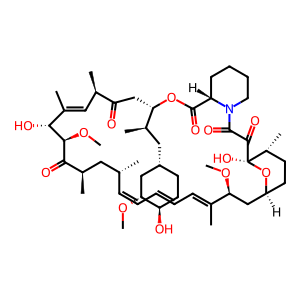

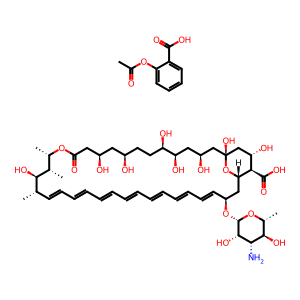

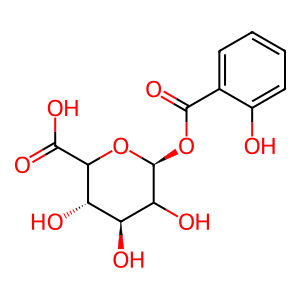

In [18]:
# I want to draw these so as to see how visually similar the molecules are
best_mol = tests['ROMol'].iloc[110]
random_mol = tests['ROMol'].iloc[140]

rapamycin_image = Draw.MolToImage(rapamycin_mol)
rapamycin_image.show()

best_image = Draw.MolToImage(best_mol)
best_image.show()

random_image = Draw.MolToImage(random_mol)
random_image.show()

Visually, these don't look THAT similar, but maybe they are compared to the other molecules in the dataset (plus the scores weren't that high either). After printing a few other molecules, it does seem to be more similar than others (they're also both pretty big molecule compared to the others).